In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

In [16]:
x = 6*np.random.rand(200,1)-3
y = 0.8*x**2 + 2 + np.random.randn(200,1)

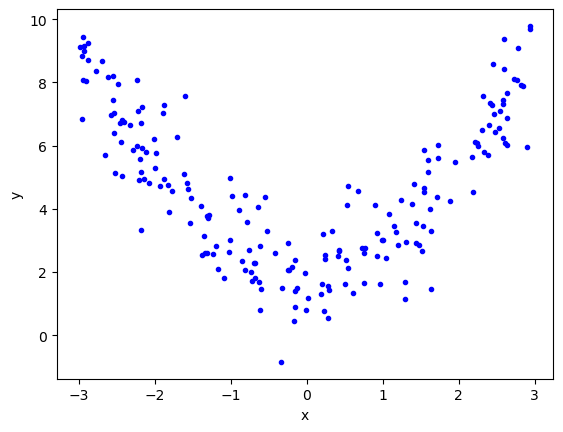

In [17]:
plt.plot(x,y,'b.')
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [18]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [19]:
reg = LinearRegression()
reg.fit(x_train,y_train)

LinearRegression()

In [21]:
y_predict = reg.predict(x_test)

In [20]:
reg.intercept_

array([4.68541924])

In [22]:
reg.coef_

array([[-0.0436925]])

In [23]:
r2_score(y_test,y_predict)

-0.005084978832365028

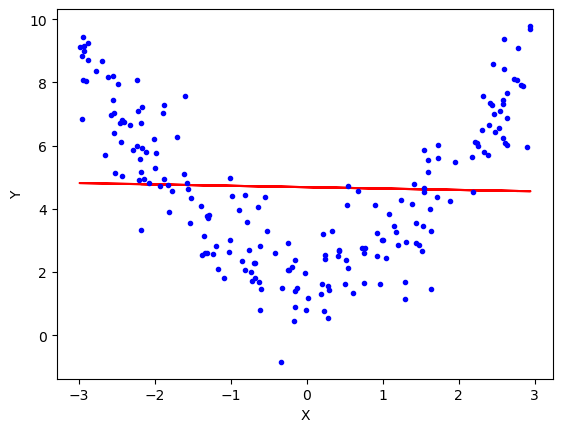

In [24]:
plt.plot(x_train,reg.predict(x_train),color='red')
plt.plot(x,y,'b.')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [25]:
# Applying polynomial linear regression
# deggree 2
poly = PolynomialFeatures(degree=2,include_bias=True) # if we use include_bias = False then x**0 will not come
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test) # we don't apply polynomial transform on y_train

In [26]:
print(x_train[0])
print(x_train_trans[0])

[2.76935063]
[1.         2.76935063 7.66930293]


In [27]:
reg.fit(x_train_trans,y_train)

LinearRegression()

In [28]:
y_predict_1=reg.predict(x_test_trans)

In [29]:
r2_score(y_test,y_predict_1)

0.8506158465052176

In [30]:
reg.coef_

array([[ 0.        , -0.00189097,  0.77866453]])

In [31]:
reg.intercept_

array([2.12388226])

In [32]:
x_new = np.linspace(-3,3,200).reshape(200,1)
x_new_poly = poly.transform(x_new)
y_new=reg.predict(x_new_poly)

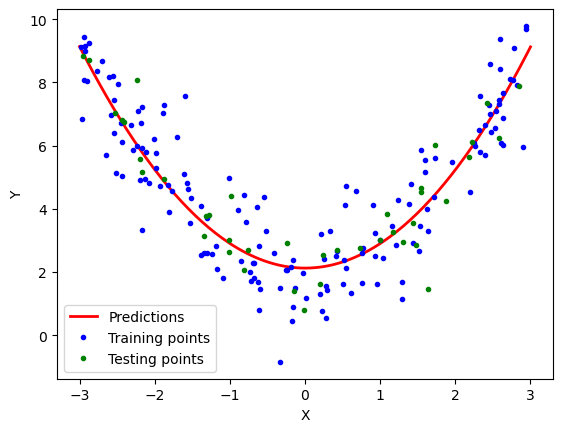

In [33]:
plt.plot(x_new , y_new , 'r-' , linewidth = 2 , label = "Predictions")
plt.plot(x_train , y_train , 'b.' ,  label = "Training points")
plt.plot(x_test , y_test , 'g.' ,  label = "Testing points")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [34]:
def Polynomial_Regresssion(degree):
    x_new = np.linspace(-3,3,200).reshape(200,1)
    x_new_poly = poly.transform(x_new)
    polybig_features = PolynomialFeatures(degree=degree,include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    Polynomial_Regresssion = Pipeline([
        ("poly_features" , polybig_features),
        ("std_scaler" , std_scaler),
        ("lin_reg" , lin_reg),
    ]) 
    Polynomial_Regresssion.fit(x,y)
    y_new_big = Polynomial_Regresssion.predict(x_new)
    plt.plot(x_new,y_new_big,'r-',label="Degree"+str(degree),linewidth=2)
    plt.plot(x_train , y_train , 'b.' , linewidth=3)
    plt.plot(x_test , y_test , 'g.' ,  linewidth = 3)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend(loc="upper left")
    plt.axis([-3,3,0,10])
    plt.show()

    


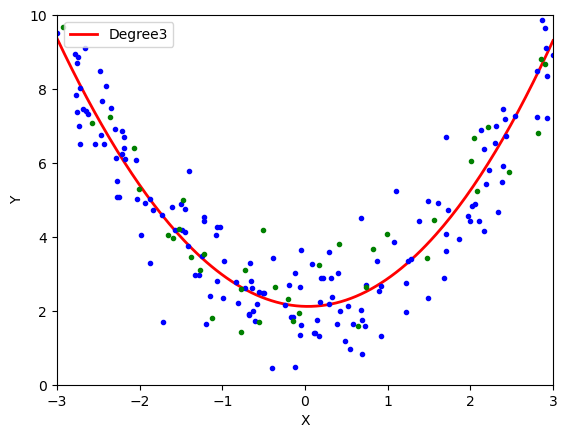

In [21]:
Polynomial_Regresssion(3)

In [4]:
# 3D polynomial regression
x1 = 7*np.random.rand(100,1) - 2.8
y1 = 7*np.random.rand(100,1) - 2.8
z = x1**2 + y1**2 + 0.2*x1 +0.2*y1 + 0.1*x1*y1 + 2  + np.random.randn(100,1)

In [6]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df , x = x1.ravel() , y = y1.ravel(), z = z.ravel())
fig.show()

In [7]:
lr = LinearRegression()
lr.fit(np.array([x1,y1]).reshape(100,2),z)
x_input = np.linspace(x1.min(),x1.max(),10)
y_input = np.linspace(y1.min(),y1.max(),10)
x1_grid , y1_grid = np.meshgrid(x_input,y_input)
final = np.vstack((x1_grid.ravel().reshape(1,100),y1_grid.ravel().reshape(1,100))).T
z_final = lr.predict(final).reshape(10,10)

In [9]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x1.ravel(), y=y1.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()


In [11]:
X_multi = np.array([x1,y1]).reshape(100,2)
X_multi.shape

(100, 2)

In [40]:
poly = PolynomialFeatures(degree=30)
X_multi_trans = poly.fit_transform(X_multi)

In [41]:
print("Input",poly.n_features_in_)
print("Ouput",poly.n_output_features_)
print("Powers\n",poly.powers_)

Input 2
Ouput 496
Powers
 [[ 0  0]
 [ 1  0]
 [ 0  1]
 [ 2  0]
 [ 1  1]
 [ 0  2]
 [ 3  0]
 [ 2  1]
 [ 1  2]
 [ 0  3]
 [ 4  0]
 [ 3  1]
 [ 2  2]
 [ 1  3]
 [ 0  4]
 [ 5  0]
 [ 4  1]
 [ 3  2]
 [ 2  3]
 [ 1  4]
 [ 0  5]
 [ 6  0]
 [ 5  1]
 [ 4  2]
 [ 3  3]
 [ 2  4]
 [ 1  5]
 [ 0  6]
 [ 7  0]
 [ 6  1]
 [ 5  2]
 [ 4  3]
 [ 3  4]
 [ 2  5]
 [ 1  6]
 [ 0  7]
 [ 8  0]
 [ 7  1]
 [ 6  2]
 [ 5  3]
 [ 4  4]
 [ 3  5]
 [ 2  6]
 [ 1  7]
 [ 0  8]
 [ 9  0]
 [ 8  1]
 [ 7  2]
 [ 6  3]
 [ 5  4]
 [ 4  5]
 [ 3  6]
 [ 2  7]
 [ 1  8]
 [ 0  9]
 [10  0]
 [ 9  1]
 [ 8  2]
 [ 7  3]
 [ 6  4]
 [ 5  5]
 [ 4  6]
 [ 3  7]
 [ 2  8]
 [ 1  9]
 [ 0 10]
 [11  0]
 [10  1]
 [ 9  2]
 [ 8  3]
 [ 7  4]
 [ 6  5]
 [ 5  6]
 [ 4  7]
 [ 3  8]
 [ 2  9]
 [ 1 10]
 [ 0 11]
 [12  0]
 [11  1]
 [10  2]
 [ 9  3]
 [ 8  4]
 [ 7  5]
 [ 6  6]
 [ 5  7]
 [ 4  8]
 [ 3  9]
 [ 2 10]
 [ 1 11]
 [ 0 12]
 [13  0]
 [12  1]
 [11  2]
 [10  3]
 [ 9  4]
 [ 8  5]
 [ 7  6]
 [ 6  7]
 [ 5  8]
 [ 4  9]
 [ 3 10]
 [ 2 11]
 [ 1 12]
 [ 0 13]
 [14  0]
 [13  1]
 [12  2]
 [

In [37]:
X_multi_trans.shape

(100, 496)

In [38]:
lr.fit(X_multi_trans,z)

LinearRegression()

In [42]:
x_test_multi = poly.transform(final)

In [43]:
z_final = lr.predict(X_multi_trans).reshape(10,10)

In [45]:
fig = px.scatter_3d(x=x1.ravel(), y=y1.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()